# PROJECT PPT
CANVA LINK  :- https://canva.link/rfu6uv1gdx6bhyn

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
import pandas as pd



Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ev ameer.csv')
data


,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,NaN,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3
2,3,NIO,ET7,2020,Calcium-ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,UK,5.0,0.0,5.0,6300,5
3,4,Audi,e-tron,2025,Lithium-iron phosphate,120.5,140,Ultra-Fast Charging (350 kW+),10.5,75615.15,Sunset Orange,Argentina,2.0,0.0,5.0,2339,5
4,5,Acura,ZDX (with GM Ultium),2023,Lithium-titanate,51.8,336,Plug-in Hydrogen Refueling,3.6,141046.94,Ice Silver,United Arab Emirates,2.0,0.0,3.0,1051,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3017,3018,Ferrari,SF90 Stradale (PHEV),2018,Sodium-ion,49.9,182,Mobile Charging,11.7,43988.90,Champagne,Indonesia,2.0,0.0,4.0,13366,5
3018,3019,Mahindra,Born Electric (upcoming range),2019,Lithium-ion,136.9,375,Vehicle-to-Home (V2H),5.8,142072.84,Electric Blue,India,NaN,0.0,3.0,15235,3
3019,3020,Cadillac,Lyriq,2021,Lithium-iron phosphate,136.5,221,Plug-in Hydrogen Refueling,1.1,88218.53,Metallic Silver,Canada,2.0,0.0,3.0,13808,3
3020,3021,Mahindra,XUV400,2021,Nickel-metal hydride,96.4,249,Mobile Charging,9.8,110221.30,Matte Green,New Zealand,3.0,NaN,3.0,9854,3




---



In [ ]:
import pandas as pd

In [ ]:
data.shape

(3022, 17)

In [ ]:
data=data.drop("CO2_Emissions_g_per_km", axis=1)

In [ ]:
data.isnull().sum()

,0
Vehicle_ID,0
Manufacturer,0
Model,0
Year,0
Battery_Type,0
Battery_Capacity_kWh,0
Range_km,0
Charging_Type,0
Charge_Time_hr,0
Price_USD,0


In [ ]:
data.head(5)

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,Safety_Rating,Units_Sold_,Warranty_Years,CO2_Saved
0,1,0,160,2015,7,55.8,214,2,9.0,111203.94,30,36,0.0,5.0,19726,3,90739.6
1,2,23,136,2025,7,90.8,212,14,7.3,127131.65,53,21,2.0,4.0,3349,3,15405.4
2,3,33,33,2020,1,64.7,235,6,8.9,94347.37,1,36,5.0,5.0,6300,5,28980.0
3,4,1,170,2025,5,120.5,140,12,10.5,75615.15,47,0,2.0,5.0,2339,5,10759.4
4,5,0,160,2023,7,51.8,336,10,3.6,141046.94,23,38,2.0,3.0,1051,4,4834.6


In [ ]:
data['Autonomous_Level'] = data['Autonomous_Level'].fillna(data['Autonomous_Level'].median())
data['Safety_Rating'] = data['Safety_Rating'].fillna(data['Safety_Rating'].median())

data.isnull().sum()

,0
Vehicle_ID,0
Manufacturer,0
Model,0
Year,0
Battery_Type,0
Battery_Capacity_kWh,0
Range_km,0
Charging_Type,0
Charge_Time_hr,0
Price_USD,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   object 
 2   Model                   3022 non-null   object 
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   object 
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   object 
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   object 
 11  Country_of_Manufacture  3022 non-null   object 
 12  Autonomous_Level        3022 non-null   float64
 13  Safety_Rating           3022 non-null   float64
 14  Units_Sold_             3022 non-null   

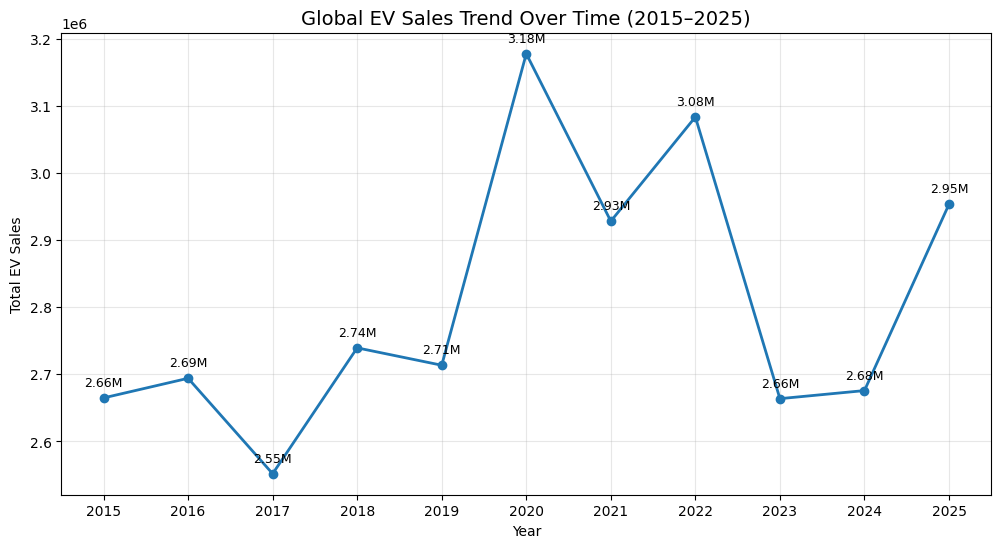

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure all years appear (2015–2025)
all_years = range(2015, 2026)

global_sales = (
    data.groupby("Year")["Units_Sold_"]
    .sum()
    .reindex(all_years, fill_value=0)
)

# Plot the trend
plt.figure(figsize=(12,6))
plt.plot(global_sales.index, global_sales.values, marker="o", linewidth=2)

# Add clean value labels (Millions format)
for x, y in zip(global_sales.index, global_sales.values):
    plt.text(x, y + (global_sales.max() * 0.004), # Adjusted for better spacing
             f"{y/1e6:.2f}M",
             ha='center', va='bottom', fontsize=9)

# Chart styling
plt.title("Global EV Sales Trend Over Time (2015–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total EV Sales")
plt.xticks(all_years)
plt.grid(alpha=0.3)

plt.show()

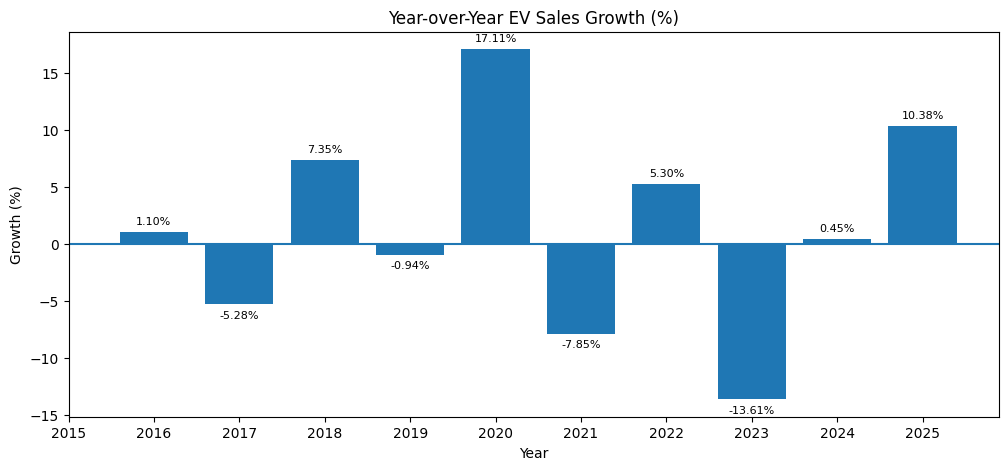

In [ ]:
growth = global_sales.pct_change() * 100

plt.figure(figsize=(12,5))
plt.bar(growth.index, growth)

for year, value in growth.items():
    if pd.notna(value):
        offset = 0.5
        plt.text(
            year,
            value + offset if value > 0 else value - offset,
            f"{value:.2f}%",
            ha='center',
            va='bottom' if value > 0 else 'top',
            fontsize=8
        )

plt.axhline(0)
plt.title("Year-over-Year EV Sales Growth (%)")
plt.xlabel("Year")
plt.ylabel("Growth (%)")


plt.xticks(growth.index)

plt.show()


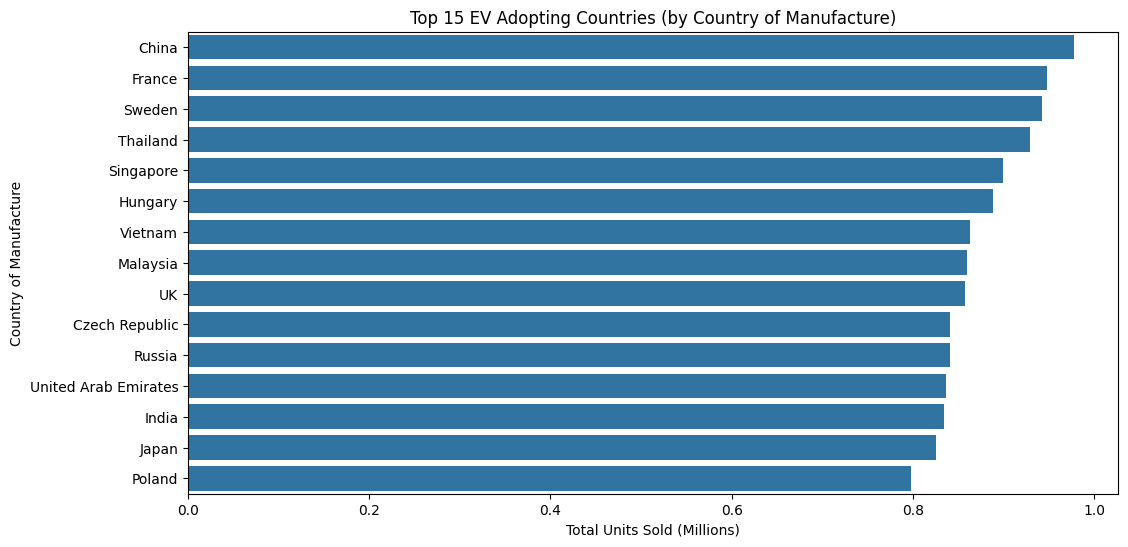

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_countries = (
    data.groupby("Country_of_Manufacture")["Units_Sold_"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

# Convert to millions
top_countries_millions = top_countries / 1e6

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_countries_millions.values,
    y=top_countries_millions.index
)

plt.title("Top 15 EV Adopting Countries (by Country of Manufacture)")
plt.xlabel("Total Units Sold (Millions)")
plt.ylabel("Country of Manufacture")

plt.show()

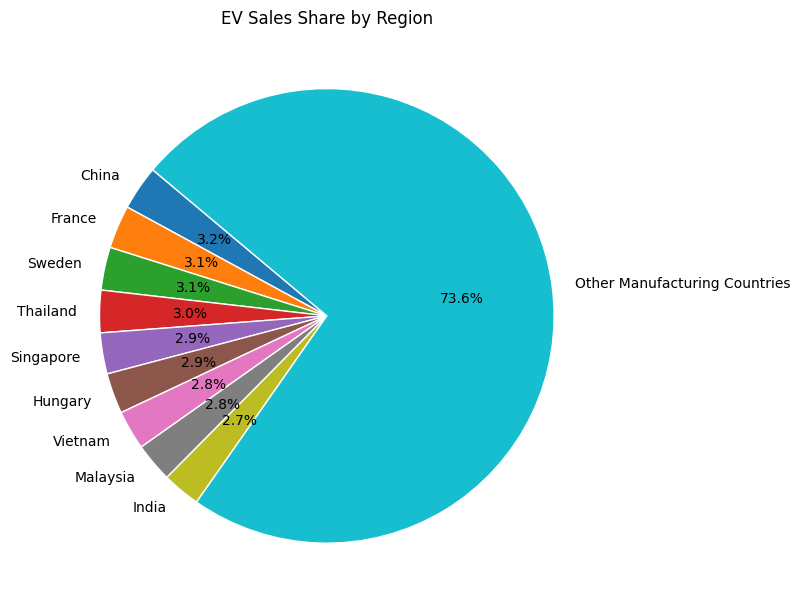

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate sales
country_sales = (
    data.groupby("Country_of_Manufacture")["Units_Sold_"]
    .sum()
    .sort_values(ascending=False)
)

top_n = 8
important_country = "India"

# Select top N
top_countries = country_sales.head(top_n)

# Force include India if not already present
if important_country not in top_countries.index:
    top_countries = pd.concat([
        top_countries,
        country_sales.loc[[important_country]]
    ])

# Remove duplicates and re-sort
top_countries = top_countries[~top_countries.index.duplicated()]
top_countries = top_countries.sort_values(ascending=False)


others = country_sales.drop(top_countries.index).sum()

pie_data = top_countries.copy()
pie_data["Other Manufacturing Countries"] = others


colors = sns.color_palette("tab10", n_colors=len(pie_data))

# Plot
plt.figure(figsize=(8,8))
plt.pie(
    pie_data,
    labels=pie_data.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 10}
)

plt.title("EV Sales Share by Region")
plt.tight_layout()
plt.show()


/tmp/ipython-input-2389/1033039704.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


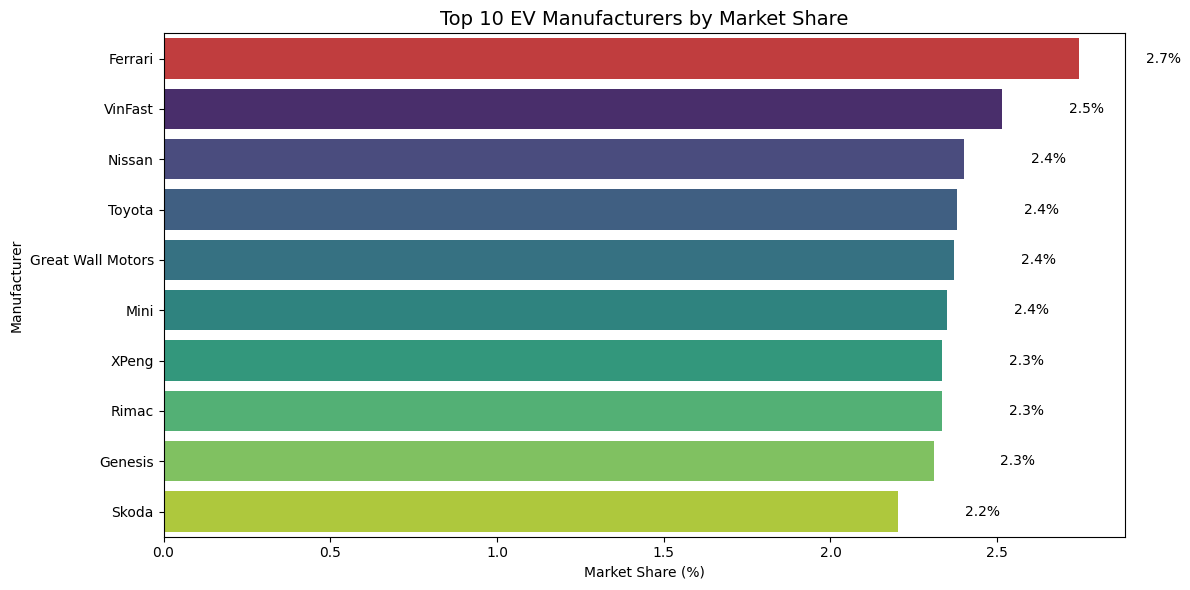

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate sales by manufacturer
brand_sales = (
    data.groupby("Manufacturer")["Units_Sold_"]
    .sum()
    .sort_values(ascending=False)
)

top_n = 10
top_brands = brand_sales.head(top_n)

market_share = (top_brands / brand_sales.sum()) * 100


colors = ["#d62728"] + sns.color_palette("viridis", n_colors=top_n-1)

plt.figure(figsize=(12,6))
sns.barplot(
    x=market_share.values,
    y=market_share.index,
    palette=colors
)

# Labels
for i, value in enumerate(market_share.values):
    plt.text(
        value + 0.2,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.title("Top 10 EV Manufacturers by Market Share", fontsize=14)
plt.xlabel("Market Share (%)")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()



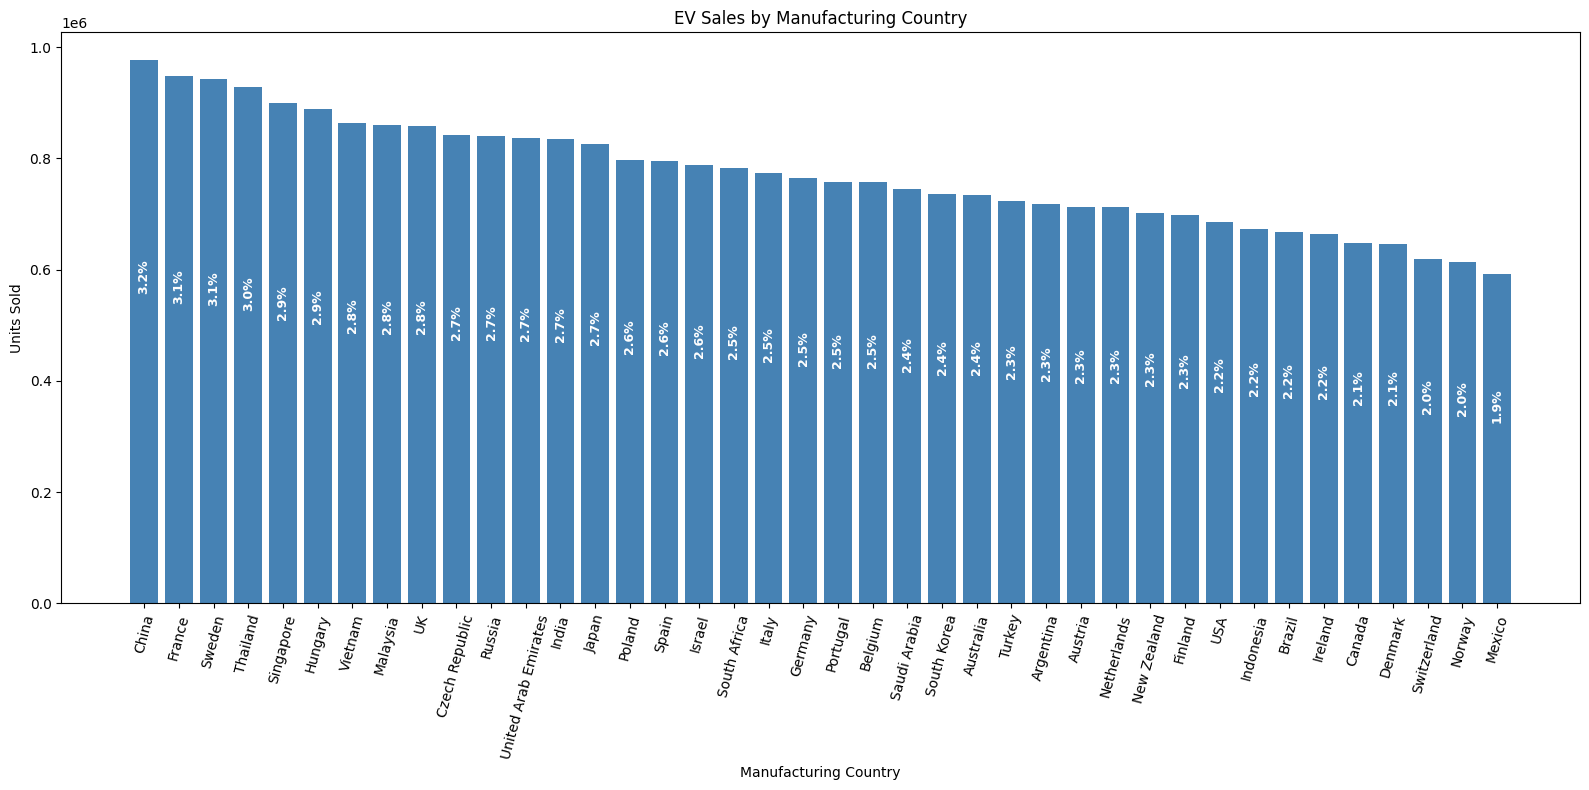

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Aggregate EV sales by manufacturing country
country_sales = (
    data.groupby("Country_of_Manufacture")["Units_Sold_"]
    .sum()
    .sort_values(ascending=False)
)

# Calculate percentage share
total_sales = country_sales.sum()
percentages = (country_sales / total_sales) * 100

# Plot
plt.figure(figsize=(16,8))

bars = plt.bar(
    country_sales.index,
    country_sales.values,
    color="steelblue"
)

plt.xlabel("Manufacturing Country")
plt.ylabel("Units Sold")
plt.title("EV Sales by Manufacturing Country")

# Rotate country names
plt.xticks(rotation=75)

# Add vertical percentage labels inside bars
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height * 0.6,          # position inside the bar
        f"{pct:.1f}%",
        ha='center',
        va='center',
        rotation=90,           # vertical text
        color='white',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

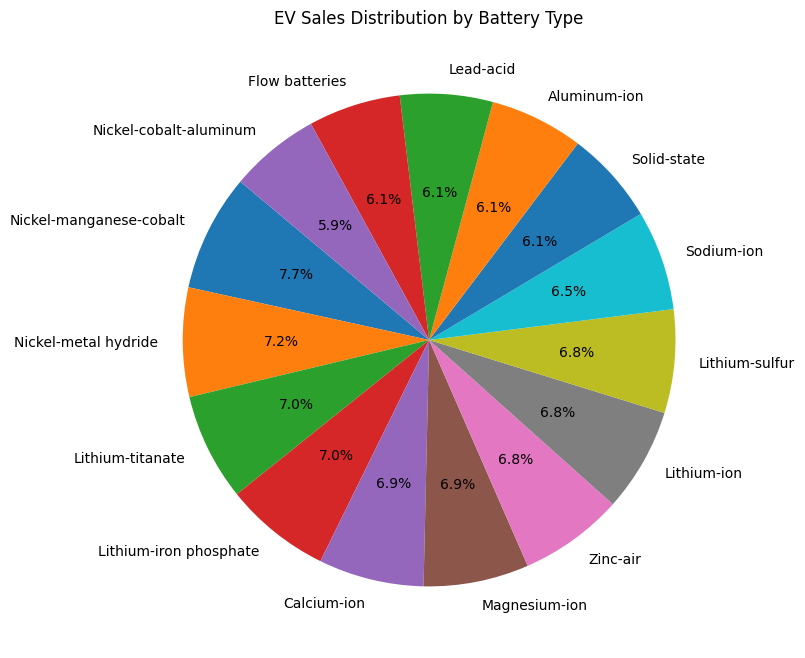

In [ ]:
ev_type_distribution = (
    data.groupby("Battery_Type")["Units_Sold_"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))
ev_type_distribution.plot(kind="pie", autopct="%1.1f%%", startangle=140)
plt.title("EV Sales Distribution by Battery Type")
plt.ylabel("")
plt.show()

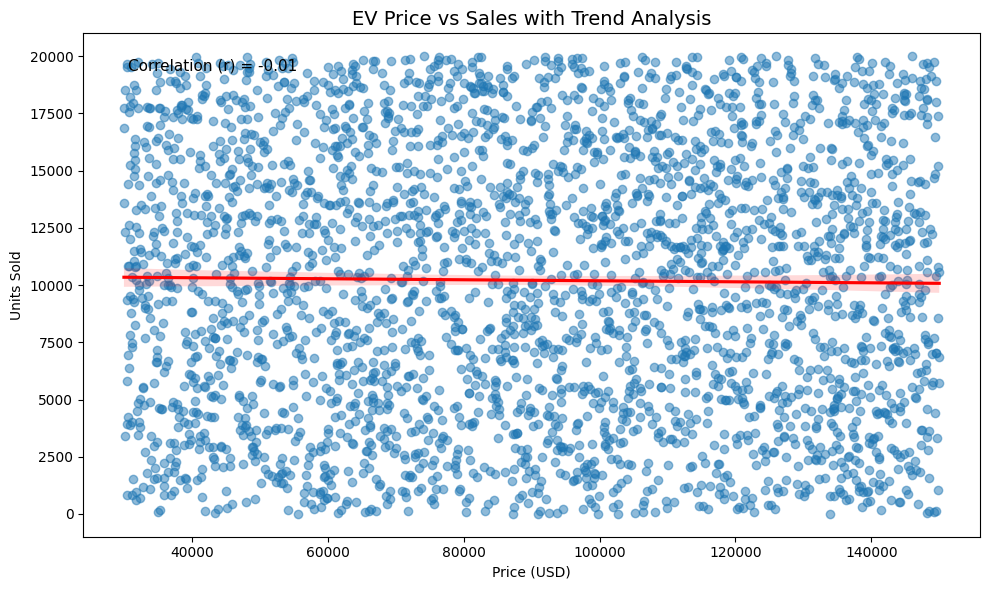

<Axes: xlabel='Price_USD', ylabel='Units_Sold_'>

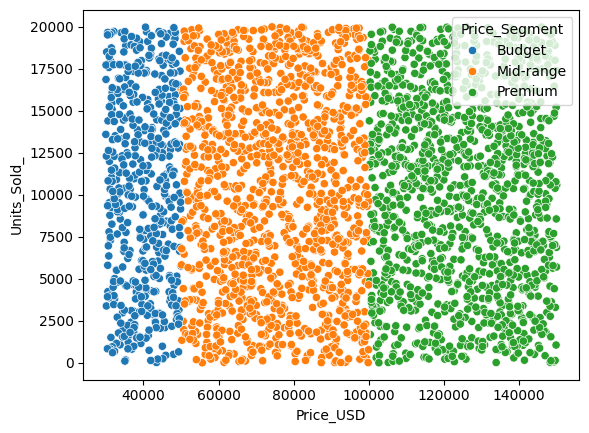

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))

# Scatter + regression line
sns.regplot(
    data=data,
    x="Price_USD",
    y="Units_Sold_",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

# Calculate correlation
corr = data["Price_USD"].corr(data["Units_Sold_"])

# Annotate correlation on plot
plt.text(
    0.05, 0.95,
    f"Correlation (r) = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top"
)

plt.title("EV Price vs Sales with Trend Analysis", fontsize=14)
plt.xlabel("Price (USD)")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

bins = [0, 50000, 100000, 150000]
labels = ["Budget", "Mid-range", "Premium"]
data["Price_Segment"] = pd.cut(data["Price_USD"], bins=bins, labels=labels)

sns.scatterplot(
    data=data,
    x="Price_USD",
    y="Units_Sold_",
    hue="Price_Segment"
)


In [ ]:
policy_year = 2019

before = data[data["Year"] < policy_year]["Units_Sold_"].mean()
after = data[data["Year"] >= policy_year]["Units_Sold_"].mean()

print("Avg Sales Before Policy:", before)
print("Avg Sales After Policy:", after)


Avg Sales Before Policy: 9897.840148698884
Avg Sales After Policy: 10378.056526207605


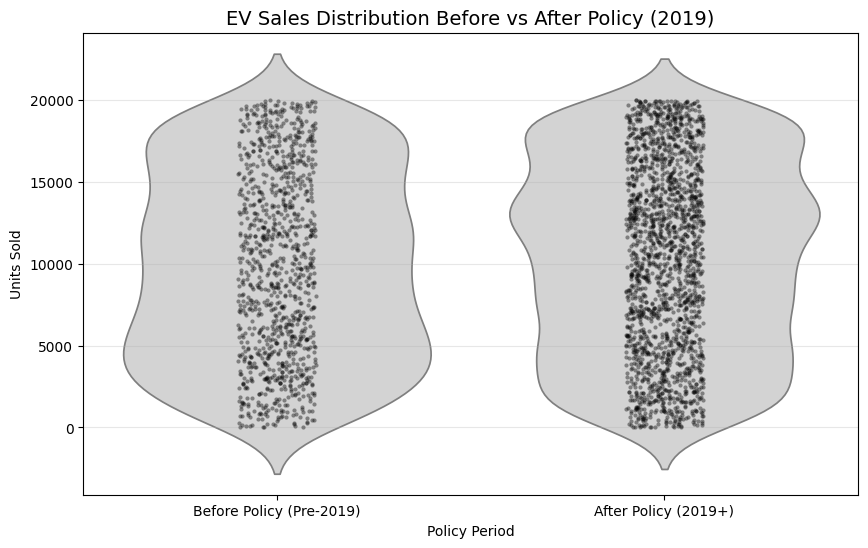

In [ ]:
policy_year = 2019

data["Policy_Period"] = data["Year"].apply(
    lambda x: "Before Policy (Pre-2019)" if x < policy_year else "After Policy (2019+)"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Violin plot
sns.violinplot(
    data=data,
    x="Policy_Period",
    y="Units_Sold_",
    inner=None,
    color="lightgray"
)

# Overlay points
sns.stripplot(
    data=data,
    x="Policy_Period",
    y="Units_Sold_",
    color="black",
    alpha=0.4,
    size=3,
    jitter=True
)

plt.title("EV Sales Distribution Before vs After Policy (2019)", fontsize=14)
plt.xlabel("Policy Period")
plt.ylabel("Units Sold")
plt.grid(axis="y", alpha=0.3)

plt.show()



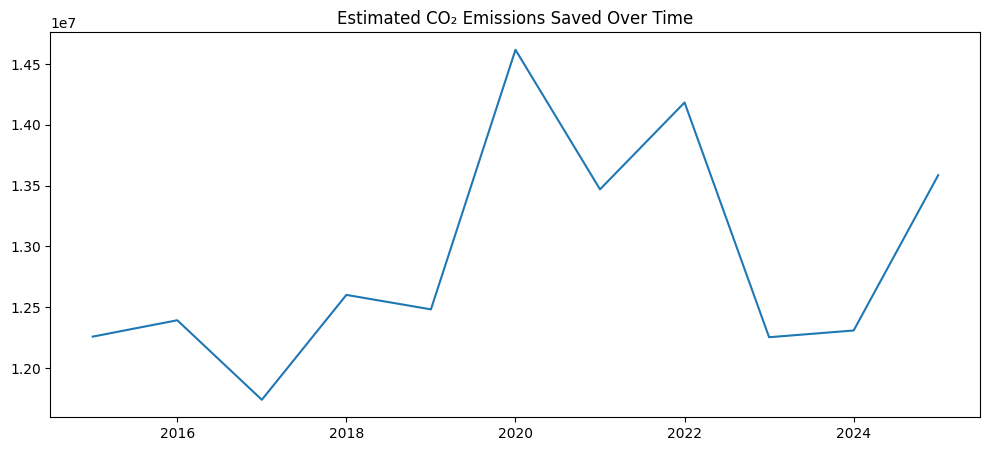

In [ ]:

data["CO2_Saved"] = data["Units_Sold_"] * 4.6   # Estimated tons saved per EV

yearly_co2 = data.groupby("Year")["CO2_Saved"].sum()

plt.figure(figsize=(12,5))
plt.plot(yearly_co2)
plt.title("Estimated CO₂ Emissions Saved Over Time")
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in data.select_dtypes(include=["object", "category"]).columns:
    data[col] = le.fit_transform(data[col])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   int64  
 2   Model                   3022 non-null   int64  
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   int64  
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   int64  
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   int64  
 11  Country_of_Manufacture  3022 non-null   int64  
 12  Autonomous_Level        3022 non-null   float64
 13  Safety_Rating           3022 non-null   float64
 14  Units_Sold_             3022 non-null   

In [ ]:
data

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,Safety_Rating,Units_Sold_,Warranty_Years,Price_Segment,Policy_Period,CO2_Saved
0,1,0,160,2015,7,55.8,214,2,9.0,111203.94,30,36,0.0,5.0,19726,3,2,1,90739.6
1,2,23,136,2025,7,90.8,212,14,7.3,127131.65,53,21,2.0,4.0,3349,3,2,0,15405.4
2,3,33,33,2020,1,64.7,235,6,8.9,94347.37,1,36,5.0,5.0,6300,5,1,0,28980.0
3,4,1,170,2025,5,120.5,140,12,10.5,75615.15,47,0,2.0,5.0,2339,5,1,0,10759.4
4,5,0,160,2023,7,51.8,336,10,3.6,141046.94,23,38,2.0,3.0,1051,4,2,0,4834.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3017,3018,11,139,2018,12,49.9,182,7,11.7,43988.90,8,14,2.0,4.0,13366,5,0,1,61483.6
3018,3019,28,10,2019,4,136.9,375,14,5.8,142072.84,15,13,3.0,3.0,15235,3,2,0,70081.0
3019,3020,4,94,2021,5,136.5,221,10,1.1,88218.53,31,5,2.0,3.0,13808,3,1,0,63516.8
3020,3021,28,159,2021,11,96.4,249,7,9.8,110221.30,29,22,3.0,3.0,9854,3,2,0,45328.4


In [ ]:
data.drop("Price_Segment", axis=1, inplace=True)

In [ ]:
data.drop("Policy_Period",axis=1, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   int64  
 2   Model                   3022 non-null   int64  
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   int64  
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   int64  
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   int64  
 11  Country_of_Manufacture  3022 non-null   int64  
 12  Autonomous_Level        3022 non-null   float64
 13  Safety_Rating           3022 non-null   float64
 14  Units_Sold_             3022 non-null   

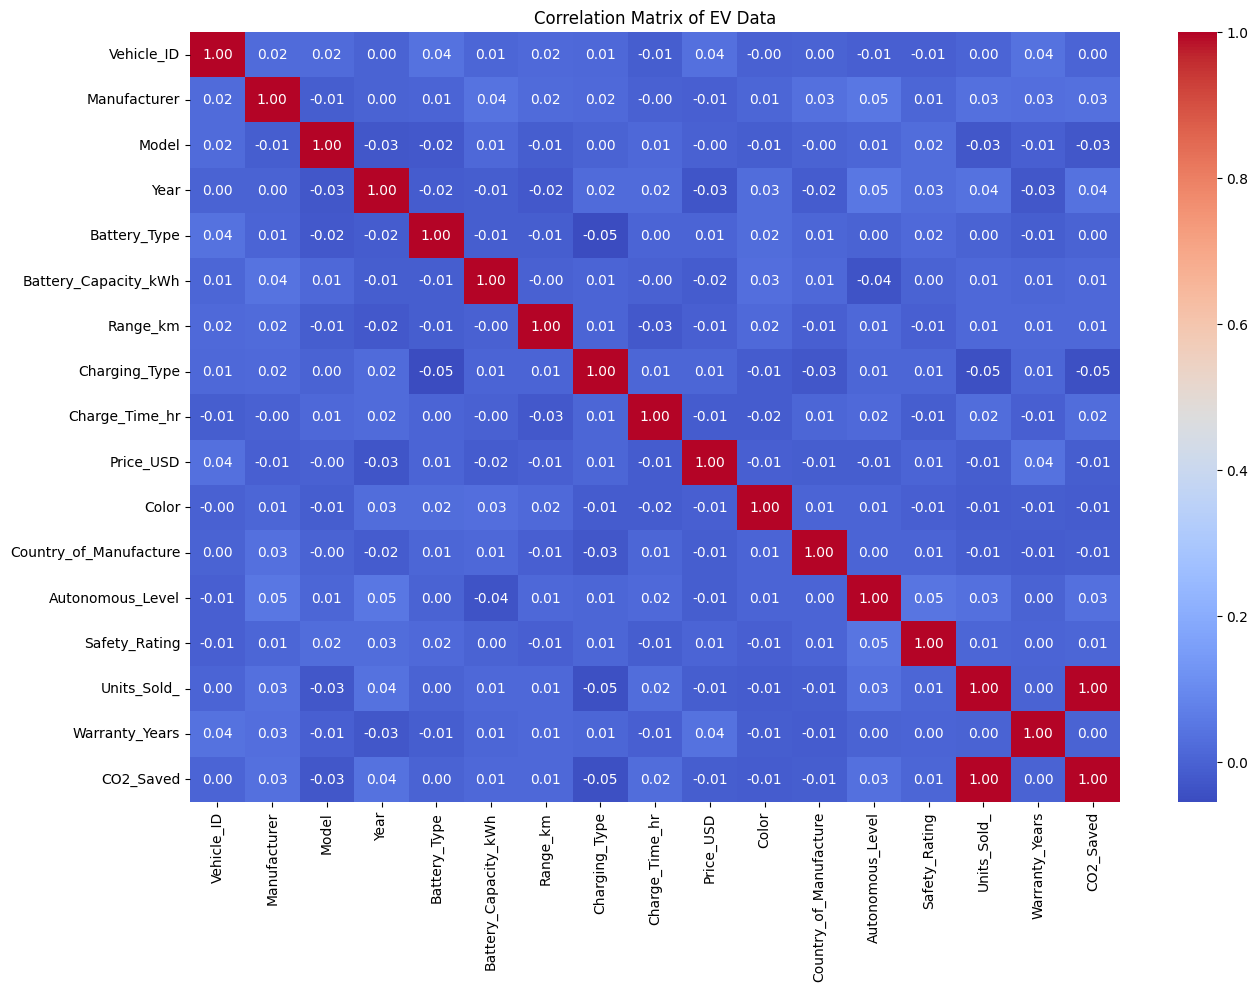

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of EV Data')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

X = data.drop('Vehicle_ID', axis=1)

# Apply Label Encoding to all non-numeric columns in X
# This will catch 'object' and 'category' dtypes, ensuring all are converted.
le = LabelEncoder()
for col in X.select_dtypes(exclude=np.number).columns:
    X[col] = le.fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 80-20

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
import numpy as np

X = X_pca
y = np.log(data['Units_Sold_'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics (LOG SCALE)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2%}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error (MSE): 0.22
Mean Absolute Error (MAE): 0.31
Mean Absolute Percentage Error (MAPE): 4.21%
R-squared: 0.74


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = model.predict(X_test)

# Evaluate the model (LOG SCALE if you used log transform earlier)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - Mean Absolute Percentage Error (MAPE): {mape_rf:.2%}")
print(f"Random Forest - R-squared: {r2_rf:.2f}")

Random Forest - Mean Squared Error (MSE): 0.04
Random Forest - Mean Absolute Error (MAE): 0.06
Random Forest - Mean Absolute Percentage Error (MAPE): 1.13%
Random Forest - R-squared: 0.95


In [ ]:
#>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = model.predict(X_test)

# Evaluate the model (LOG SCALE if using log target)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree - Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Decision Tree - Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Decision Tree - Mean Absolute Percentage Error (MAPE): {mape_dt:.2%}")
print(f"Decision Tree - R-squared: {r2_dt:.2f}")

Decision Tree - Mean Squared Error (MSE): 0.07
Decision Tree - Mean Absolute Error (MAE): 0.09
Decision Tree - Mean Absolute Percentage Error (MAPE): 1.43%
Decision Tree - R-squared: 0.92


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Support Vector Regressor model
model = SVR()   # default kernel='rbf'
model.fit(X_train, y_train)

# Make predictions
y_pred_svr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100
r2_svr = r2_score(y_test, y_pred_svr)

# Print results in same format
print(f"Support Vector Regressor - Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Percentage Error (MAPE): {mape_svr:.2f}%")
print(f"Support Vector Regressor - R-squared: {r2_svr:.2f}")

Support Vector Regressor - Mean Squared Error (MSE): 0.12
Support Vector Regressor - Mean Absolute Error (MAE): 0.14
Support Vector Regressor - Mean Absolute Percentage Error (MAPE): 2.31%
Support Vector Regressor - R-squared: 0.86


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the XGBoost Regressor model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print results in same format
print(f"XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_xgb:.2f}%")
print(f"XGBoost Regressor - R-squared: {r2_xgb:.2f}")

XGBoost Regressor - Mean Squared Error (MSE): 0.04
XGBoost Regressor - Mean Absolute Error (MAE): 0.05
XGBoost Regressor - Mean Absolute Percentage Error (MAPE): 0.97%
XGBoost Regressor - R-squared: 0.96


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the KNN Regressor model
model = KNeighborsRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred_knn = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
r2_knn = r2_score(y_test, y_pred_knn)

# Print results in same format
print(f"K-Nearest Neighbors Regressor - Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): {mape_knn:.2f}%")
print(f"K-Nearest Neighbors Regressor - R-squared: {r2_knn:.2f}")

K-Nearest Neighbors Regressor - Mean Squared Error (MSE): 0.26
K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): 0.25
K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): 3.76%
K-Nearest Neighbors Regressor - R-squared: 0.69


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Lasso Regressor model
model = Lasso(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results in same format
print(f"Lasso Regressor - Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Percentage Error (MAPE): {mape_lasso:.2f}%")
print(f"Lasso Regressor - R-squared: {r2_lasso:.2f}")

Lasso Regressor - Mean Squared Error (MSE): 0.63
Lasso Regressor - Mean Absolute Error (MAE): 0.56
Lasso Regressor - Mean Absolute Percentage Error (MAPE): 7.43%
Lasso Regressor - R-squared: 0.26


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Ridge Regressor model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print results in same format
print(f"Ridge Regressor - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Percentage Error (MAPE): {mape_ridge:.2f}%")
print(f"Ridge Regressor - R-squared: {r2_ridge:.2f}")

Ridge Regressor - Mean Squared Error (MSE): 0.22
Ridge Regressor - Mean Absolute Error (MAE): 0.31
Ridge Regressor - Mean Absolute Percentage Error (MAPE): 4.21%
Ridge Regressor - R-squared: 0.74


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_gbr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print results in same format
print(f"Gradient Boosting Regressor - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): {mape_gbr:.2f}%")
print(f"Gradient Boosting Regressor - R-squared: {r2_gbr:.2f}")

Gradient Boosting Regressor - Mean Squared Error (MSE): 0.04
Gradient Boosting Regressor - Mean Absolute Error (MAE): 0.06
Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): 1.04%
Gradient Boosting Regressor - R-squared: 0.95


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the AdaBoost Regressor model
model = AdaBoostRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ada = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100
r2_ada = r2_score(y_test, y_pred_ada)

# Print results in same format
print(f"AdaBoost Regressor - Mean Squared Error (MSE): {mse_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Error (MAE): {mae_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_ada:.2f}%")
print(f"AdaBoost Regressor - R-squared: {r2_ada:.2f}")

AdaBoost Regressor - Mean Squared Error (MSE): 0.08
AdaBoost Regressor - Mean Absolute Error (MAE): 0.16
AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): 2.21%
AdaBoost Regressor - R-squared: 0.91


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Bagging Regressor model
model = BaggingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_bag = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mae_bag = mean_absolute_error(y_test, y_pred_bag)
mape_bag = np.mean(np.abs((y_test - y_pred_bag) / y_test)) * 100
r2_bag = r2_score(y_test, y_pred_bag)

# Print results in same format
print(f"Bagging Regressor - Mean Squared Error (MSE): {mse_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Error (MAE): {mae_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Percentage Error (MAPE): {mape_bag:.2f}%")
print(f"Bagging Regressor - R-squared: {r2_bag:.2f}")

Bagging Regressor - Mean Squared Error (MSE): 0.04
Bagging Regressor - Mean Absolute Error (MAE): 0.07
Bagging Regressor - Mean Absolute Percentage Error (MAPE): 1.15%
Bagging Regressor - R-squared: 0.95


In [ ]:
import sys
!{sys.executable} -m pip install catboost

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the CatBoost Regressor model
model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred_cat = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
r2_cat = r2_score(y_test, y_pred_cat)

# Print results in same format
print(f"CatBoost Regressor - Mean Squared Error (MSE): {mse_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Error (MAE): {mae_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_cat:.2f}%")
print(f"CatBoost Regressor - R-squared: {r2_cat:.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
CatBoost Regressor - Mean Squared Error (MSE): 0.04
CatBoost Regressor - Mean Absolute Error (MAE): 0.04
CatBoost Regressor - Mean Absolute Percentage Error (MAPE): 0.84%
CatBoost Regressor - R-squared: 0.96


##70-30

In [ ]:
X = X_pca
y = np.log(data['Units_Sold_'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_lr = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

# Print results in same format
print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression - Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Linear Regression - Mean Absolute Percentage Error (MAPE): {mape_lr:.2f}%")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")

Linear Regression - Mean Squared Error (MSE): 0.27
Linear Regression - Mean Absolute Error (MAE): 0.32
Linear Regression - Mean Absolute Percentage Error (MAPE): 4.55%
Linear Regression - R-squared: 0.72


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_rf = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2_rf = r2_score(y_test, y_pred_rf)

# Print results in same format
print(f"Random Forest Regressor - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Percentage Error (MAPE): {mape_rf:.2f}%")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

Random Forest Regressor - Mean Squared Error (MSE): 0.07
Random Forest Regressor - Mean Absolute Error (MAE): 0.07
Random Forest Regressor - Mean Absolute Percentage Error (MAPE): 1.41%
Random Forest Regressor - R-squared: 0.92


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_dt = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
r2_dt = r2_score(y_test, y_pred_dt)

# Print results in same format
print(f"Decision Tree Regressor - Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): {mape_dt:.2f}%")
print(f"Decision Tree Regressor - R-squared: {r2_dt:.2f}")

Decision Tree Regressor - Mean Squared Error (MSE): 0.08
Decision Tree Regressor - Mean Absolute Error (MAE): 0.10
Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): 1.70%
Decision Tree Regressor - R-squared: 0.92


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Support Vector Regressor model
model = SVR()   # default kernel='rbf'
model.fit(X_train, y_train)

# Make predictions
y_pred_svr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100
r2_svr = r2_score(y_test, y_pred_svr)

# Print results in same format
print(f"Support Vector Regressor - Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Percentage Error (MAPE): {mape_svr:.2f}%")
print(f"Support Vector Regressor - R-squared: {r2_svr:.2f}")

Support Vector Regressor - Mean Squared Error (MSE): 0.17
Support Vector Regressor - Mean Absolute Error (MAE): 0.16
Support Vector Regressor - Mean Absolute Percentage Error (MAPE): 2.68%
Support Vector Regressor - R-squared: 0.83


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the XGBoost Regressor model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print results in same format
print(f"XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_xgb:.2f}%")
print(f"XGBoost Regressor - R-squared: {r2_xgb:.2f}")

XGBoost Regressor - Mean Squared Error (MSE): 0.07
XGBoost Regressor - Mean Absolute Error (MAE): 0.06
XGBoost Regressor - Mean Absolute Percentage Error (MAPE): 1.26%
XGBoost Regressor - R-squared: 0.93


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the KNN Regressor model
model = KNeighborsRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred_knn = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
r2_knn = r2_score(y_test, y_pred_knn)

# Print results in same format
print(f"K-Nearest Neighbors Regressor - Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): {mape_knn:.2f}%")
print(f"K-Nearest Neighbors Regressor - R-squared: {r2_knn:.2f}")

K-Nearest Neighbors Regressor - Mean Squared Error (MSE): 0.34
K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): 0.27
K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): 4.24%
K-Nearest Neighbors Regressor - R-squared: 0.65


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Lasso Regressor model
model = Lasso(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results in same format
print(f"Lasso Regressor - Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Percentage Error (MAPE): {mape_lasso:.2f}%")
print(f"Lasso Regressor - R-squared: {r2_lasso:.2f}")

Lasso Regressor - Mean Squared Error (MSE): 0.73
Lasso Regressor - Mean Absolute Error (MAE): 0.58
Lasso Regressor - Mean Absolute Percentage Error (MAPE): 7.89%
Lasso Regressor - R-squared: 0.24


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Ridge Regressor model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print results in same format
print(f"Ridge Regressor - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Percentage Error (MAPE): {mape_ridge:.2f}%")
print(f"Ridge Regressor - R-squared: {r2_ridge:.2f}")

Ridge Regressor - Mean Squared Error (MSE): 0.27
Ridge Regressor - Mean Absolute Error (MAE): 0.32
Ridge Regressor - Mean Absolute Percentage Error (MAPE): 4.54%
Ridge Regressor - R-squared: 0.72


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_gbr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print results in same format
print(f"Gradient Boosting Regressor - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): {mape_gbr:.2f}%")
print(f"Gradient Boosting Regressor - R-squared: {r2_gbr:.2f}")

Gradient Boosting Regressor - Mean Squared Error (MSE): 0.06
Gradient Boosting Regressor - Mean Absolute Error (MAE): 0.06
Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): 1.25%
Gradient Boosting Regressor - R-squared: 0.94


In [ ]:
from sklearn.ensemble import AdaBoostRegressor

# Initialize and train the AdaBoost Regressor model
model = AdaBoostRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = model.predict(X_test)

# Evaluate the model
mse_ada = mean_squared_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print(f"AdaBoost Regressor - Mean Squared Error: {mse_ada:.2f}")
print(f"AdaBoost Regressor - R-squared: {r2_ada:.2f}")

AdaBoost Regressor - Mean Squared Error: 0.09
AdaBoost Regressor - R-squared: 0.91


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the AdaBoost Regressor model
model = AdaBoostRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ada = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100
r2_ada = r2_score(y_test, y_pred_ada)

# Print results in same format
print(f"AdaBoost Regressor - Mean Squared Error (MSE): {mse_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Error (MAE): {mae_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_ada:.2f}%")
print(f"AdaBoost Regressor - R-squared: {r2_ada:.2f}")

AdaBoost Regressor - Mean Squared Error (MSE): 0.09
AdaBoost Regressor - Mean Absolute Error (MAE): 0.15
AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): 2.22%
AdaBoost Regressor - R-squared: 0.91


In [ ]:


from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the CatBoost Regressor model
model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred_cat = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
r2_cat = r2_score(y_test, y_pred_cat)

# Print results in same format
print(f"CatBoost Regressor - Mean Squared Error (MSE): {mse_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Error (MAE): {mae_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_cat:.2f}%")
print(f"CatBoost Regressor - R-squared: {r2_cat:.2f}")

CatBoost Regressor - Mean Squared Error (MSE): 0.05
CatBoost Regressor - Mean Absolute Error (MAE): 0.05
CatBoost Regressor - Mean Absolute Percentage Error (MAPE): 1.03%
CatBoost Regressor - R-squared: 0.94


# 60-40

In [ ]:
X = X_pca
y = np.log(data['Units_Sold_'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_lr = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

# Print results in same format
print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression - Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Linear Regression - Mean Absolute Percentage Error (MAPE): {mape_lr:.2f}%")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")

Linear Regression - Mean Squared Error (MSE): 0.26
Linear Regression - Mean Absolute Error (MAE): 0.32
Linear Regression - Mean Absolute Percentage Error (MAPE): 4.45%
Linear Regression - R-squared: 0.73


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_rf = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2_rf = r2_score(y_test, y_pred_rf)

# Print results in same format
print(f"Random Forest Regressor - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Percentage Error (MAPE): {mape_rf:.2f}%")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

Random Forest Regressor - Mean Squared Error (MSE): 0.08
Random Forest Regressor - Mean Absolute Error (MAE): 0.08
Random Forest Regressor - Mean Absolute Percentage Error (MAPE): 1.42%
Random Forest Regressor - R-squared: 0.92


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_dt = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
r2_dt = r2_score(y_test, y_pred_dt)

# Print results in same format
print(f"Decision Tree Regressor - Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): {mape_dt:.2f}%")
print(f"Decision Tree Regressor - R-squared: {r2_dt:.2f}")

Decision Tree Regressor - Mean Squared Error (MSE): 0.13
Decision Tree Regressor - Mean Absolute Error (MAE): 0.12
Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): 1.89%
Decision Tree Regressor - R-squared: 0.86


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Support Vector Regressor model
model = SVR()   # default kernel='rbf'
model.fit(X_train, y_train)

# Make predictions
y_pred_svr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100
r2_svr = r2_score(y_test, y_pred_svr)

# Print results in same format
print(f"Support Vector Regressor - Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Percentage Error (MAPE): {mape_svr:.2f}%")
print(f"Support Vector Regressor - R-squared: {r2_svr:.2f}")

Support Vector Regressor - Mean Squared Error (MSE): 0.17
Support Vector Regressor - Mean Absolute Error (MAE): 0.17
Support Vector Regressor - Mean Absolute Percentage Error (MAPE): 2.69%
Support Vector Regressor - R-squared: 0.83


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the XGBoost Regressor model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print results in same format
print(f"XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_xgb:.2f}%")
print(f"XGBoost Regressor - R-squared: {r2_xgb:.2f}")

XGBoost Regressor - Mean Squared Error (MSE): 0.06
XGBoost Regressor - Mean Absolute Error (MAE): 0.06
XGBoost Regressor - Mean Absolute Percentage Error (MAPE): 1.18%
XGBoost Regressor - R-squared: 0.94


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the KNN Regressor model
model = KNeighborsRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred_knn = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
r2_knn = r2_score(y_test, y_pred_knn)

# Print results in same format
print(f"K-Nearest Neighbors Regressor - Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): {mape_knn:.2f}%")
print(f"K-Nearest Neighbors Regressor - R-squared: {r2_knn:.2f}")

K-Nearest Neighbors Regressor - Mean Squared Error (MSE): 0.33
K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): 0.28
K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): 4.20%
K-Nearest Neighbors Regressor - R-squared: 0.67


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Lasso Regressor model
model = Lasso(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results in same format
print(f"Lasso Regressor - Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Percentage Error (MAPE): {mape_lasso:.2f}%")
print(f"Lasso Regressor - R-squared: {r2_lasso:.2f}")

Lasso Regressor - Mean Squared Error (MSE): 0.75
Lasso Regressor - Mean Absolute Error (MAE): 0.59
Lasso Regressor - Mean Absolute Percentage Error (MAPE): 7.97%
Lasso Regressor - R-squared: 0.23


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Ridge Regressor model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print results in same format
print(f"Ridge Regressor - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Percentage Error (MAPE): {mape_ridge:.2f}%")
print(f"Ridge Regressor - R-squared: {r2_ridge:.2f}")

Ridge Regressor - Mean Squared Error (MSE): 0.26
Ridge Regressor - Mean Absolute Error (MAE): 0.32
Ridge Regressor - Mean Absolute Percentage Error (MAPE): 4.45%
Ridge Regressor - R-squared: 0.73


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_gbr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print results in same format
print(f"Gradient Boosting Regressor - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): {mape_gbr:.2f}%")
print(f"Gradient Boosting Regressor - R-squared: {r2_gbr:.2f}")

Gradient Boosting Regressor - Mean Squared Error (MSE): 0.06
Gradient Boosting Regressor - Mean Absolute Error (MAE): 0.07
Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): 1.18%
Gradient Boosting Regressor - R-squared: 0.94


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the AdaBoost Regressor model
model = AdaBoostRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ada = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100
r2_ada = r2_score(y_test, y_pred_ada)

# Print results in same format
print(f"AdaBoost Regressor - Mean Squared Error (MSE): {mse_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Error (MAE): {mae_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_ada:.2f}%")
print(f"AdaBoost Regressor - R-squared: {r2_ada:.2f}")

AdaBoost Regressor - Mean Squared Error (MSE): 0.08
AdaBoost Regressor - Mean Absolute Error (MAE): 0.16
AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): 2.19%
AdaBoost Regressor - R-squared: 0.92


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Bagging Regressor model
model = BaggingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_bag = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mae_bag = mean_absolute_error(y_test, y_pred_bag)
mape_bag = np.mean(np.abs((y_test - y_pred_bag) / y_test)) * 100
r2_bag = r2_score(y_test, y_pred_bag)

# Print results in same format
print(f"Bagging Regressor - Mean Squared Error (MSE): {mse_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Error (MAE): {mae_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Percentage Error (MAPE): {mape_bag:.2f}%")
print(f"Bagging Regressor - R-squared: {r2_bag:.2f}")

Bagging Regressor - Mean Squared Error (MSE): 0.07
Bagging Regressor - Mean Absolute Error (MAE): 0.08
Bagging Regressor - Mean Absolute Percentage Error (MAPE): 1.45%
Bagging Regressor - R-squared: 0.93


In [ ]:


from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the CatBoost Regressor model
model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred_cat = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
r2_cat = r2_score(y_test, y_pred_cat)

# Print results in same format
print(f"CatBoost Regressor - Mean Squared Error (MSE): {mse_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Error (MAE): {mae_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_cat:.2f}%")
print(f"CatBoost Regressor - R-squared: {r2_cat:.2f}")

CatBoost Regressor - Mean Squared Error (MSE): 0.04
CatBoost Regressor - Mean Absolute Error (MAE): 0.04
CatBoost Regressor - Mean Absolute Percentage Error (MAPE): 0.91%
CatBoost Regressor - R-squared: 0.96


# 85-15

In [ ]:
X = X_pca
y = np.log(data['Units_Sold_'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_lr = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

# Print results in same format
print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression - Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Linear Regression - Mean Absolute Percentage Error (MAPE): {mape_lr:.2f}%")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")

Linear Regression - Mean Squared Error (MSE): 0.24
Linear Regression - Mean Absolute Error (MAE): 0.31
Linear Regression - Mean Absolute Percentage Error (MAPE): 4.41%
Linear Regression - R-squared: 0.73


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_rf = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2_rf = r2_score(y_test, y_pred_rf)

# Print results in same format
print(f"Random Forest Regressor - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Percentage Error (MAPE): {mape_rf:.2f}%")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

Random Forest Regressor - Mean Squared Error (MSE): 0.06
Random Forest Regressor - Mean Absolute Error (MAE): 0.07
Random Forest Regressor - Mean Absolute Percentage Error (MAPE): 1.34%
Random Forest Regressor - R-squared: 0.94


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_dt = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
r2_dt = r2_score(y_test, y_pred_dt)

# Print results in same format
print(f"Decision Tree Regressor - Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): {mape_dt:.2f}%")
print(f"Decision Tree Regressor - R-squared: {r2_dt:.2f}")

Decision Tree Regressor - Mean Squared Error (MSE): 0.11
Decision Tree Regressor - Mean Absolute Error (MAE): 0.11
Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): 1.85%
Decision Tree Regressor - R-squared: 0.88


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Support Vector Regressor model
model = SVR()   # default kernel='rbf'
model.fit(X_train, y_train)

# Make predictions
y_pred_svr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100
r2_svr = r2_score(y_test, y_pred_svr)

# Print results in same format
print(f"Support Vector Regressor - Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Percentage Error (MAPE): {mape_svr:.2f}%")
print(f"Support Vector Regressor - R-squared: {r2_svr:.2f}")

Support Vector Regressor - Mean Squared Error (MSE): 0.14
Support Vector Regressor - Mean Absolute Error (MAE): 0.14
Support Vector Regressor - Mean Absolute Percentage Error (MAPE): 2.46%
Support Vector Regressor - R-squared: 0.85


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the XGBoost Regressor model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print results in same format
print(f"XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_xgb:.2f}%")
print(f"XGBoost Regressor - R-squared: {r2_xgb:.2f}")

XGBoost Regressor - Mean Squared Error (MSE): 0.03
XGBoost Regressor - Mean Absolute Error (MAE): 0.05
XGBoost Regressor - Mean Absolute Percentage Error (MAPE): 0.89%
XGBoost Regressor - R-squared: 0.97


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the KNN Regressor model
model = KNeighborsRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred_knn = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
r2_knn = r2_score(y_test, y_pred_knn)

# Print results in same format
print(f"K-Nearest Neighbors Regressor - Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): {mape_knn:.2f}%")
print(f"K-Nearest Neighbors Regressor - R-squared: {r2_knn:.2f}")

K-Nearest Neighbors Regressor - Mean Squared Error (MSE): 0.29
K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): 0.26
K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): 4.02%
K-Nearest Neighbors Regressor - R-squared: 0.68


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Lasso Regressor model
model = Lasso(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results in same format
print(f"Lasso Regressor - Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Percentage Error (MAPE): {mape_lasso:.2f}%")
print(f"Lasso Regressor - R-squared: {r2_lasso:.2f}")

Lasso Regressor - Mean Squared Error (MSE): 0.69
Lasso Regressor - Mean Absolute Error (MAE): 0.58
Lasso Regressor - Mean Absolute Percentage Error (MAPE): 7.89%
Lasso Regressor - R-squared: 0.24


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Ridge Regressor model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print results in same format
print(f"Ridge Regressor - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Percentage Error (MAPE): {mape_ridge:.2f}%")
print(f"Ridge Regressor - R-squared: {r2_ridge:.2f}")

Ridge Regressor - Mean Squared Error (MSE): 0.24
Ridge Regressor - Mean Absolute Error (MAE): 0.31
Ridge Regressor - Mean Absolute Percentage Error (MAPE): 4.41%
Ridge Regressor - R-squared: 0.73


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_gbr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print results in same format
print(f"Gradient Boosting Regressor - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): {mape_gbr:.2f}%")
print(f"Gradient Boosting Regressor - R-squared: {r2_gbr:.2f}")

Gradient Boosting Regressor - Mean Squared Error (MSE): 0.06
Gradient Boosting Regressor - Mean Absolute Error (MAE): 0.06
Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): 1.19%
Gradient Boosting Regressor - R-squared: 0.94


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the AdaBoost Regressor model
model = AdaBoostRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ada = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100
r2_ada = r2_score(y_test, y_pred_ada)

# Print results in same format
print(f"AdaBoost Regressor - Mean Squared Error (MSE): {mse_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Error (MAE): {mae_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_ada:.2f}%")
print(f"AdaBoost Regressor - R-squared: {r2_ada:.2f}")

AdaBoost Regressor - Mean Squared Error (MSE): 0.08
AdaBoost Regressor - Mean Absolute Error (MAE): 0.16
AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): 2.34%
AdaBoost Regressor - R-squared: 0.91


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Bagging Regressor model
model = BaggingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_bag = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mae_bag = mean_absolute_error(y_test, y_pred_bag)
mape_bag = np.mean(np.abs((y_test - y_pred_bag) / y_test)) * 100
r2_bag = r2_score(y_test, y_pred_bag)

# Print results in same format
print(f"Bagging Regressor - Mean Squared Error (MSE): {mse_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Error (MAE): {mae_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Percentage Error (MAPE): {mape_bag:.2f}%")
print(f"Bagging Regressor - R-squared: {r2_bag:.2f}")

Bagging Regressor - Mean Squared Error (MSE): 0.07
Bagging Regressor - Mean Absolute Error (MAE): 0.07
Bagging Regressor - Mean Absolute Percentage Error (MAPE): 1.41%
Bagging Regressor - R-squared: 0.92


In [ ]:


# Initialize and train the CatBoost Regressor model
model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred_cat = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
r2_cat = r2_score(y_test, y_pred_cat)

# Print results in same format
print(f"CatBoost Regressor - Mean Squared Error (MSE): {mse_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Error (MAE): {mae_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_cat:.2f}%")
print(f"CatBoost Regressor - R-squared: {r2_cat:.2f}")

CatBoost Regressor - Mean Squared Error (MSE): 0.05
CatBoost Regressor - Mean Absolute Error (MAE): 0.04
CatBoost Regressor - Mean Absolute Percentage Error (MAPE): 1.01%
CatBoost Regressor - R-squared: 0.95


# 75-25

In [ ]:
X = X_pca
y = np.log(data['Units_Sold_'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_lr = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

# Print results in same format
print(f"Linear Regression - Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Linear Regression - Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Linear Regression - Mean Absolute Percentage Error (MAPE): {mape_lr:.2f}%")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")

Linear Regression - Mean Squared Error (MSE): 0.26
Linear Regression - Mean Absolute Error (MAE): 0.32
Linear Regression - Mean Absolute Percentage Error (MAPE): 4.46%
Linear Regression - R-squared: 0.72


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_rf = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2_rf = r2_score(y_test, y_pred_rf)

# Print results in same format
print(f"Random Forest Regressor - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest Regressor - Mean Absolute Percentage Error (MAPE): {mape_rf:.2f}%")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

Random Forest Regressor - Mean Squared Error (MSE): 0.06
Random Forest Regressor - Mean Absolute Error (MAE): 0.07
Random Forest Regressor - Mean Absolute Percentage Error (MAPE): 1.29%
Random Forest Regressor - R-squared: 0.94


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_dt = model.predict(X_test)

# Evaluate the model (same metrics as other models)
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
r2_dt = r2_score(y_test, y_pred_dt)

# Print results in same format
print(f"Decision Tree Regressor - Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): {mape_dt:.2f}%")
print(f"Decision Tree Regressor - R-squared: {r2_dt:.2f}")

Decision Tree Regressor - Mean Squared Error (MSE): 0.11
Decision Tree Regressor - Mean Absolute Error (MAE): 0.10
Decision Tree Regressor - Mean Absolute Percentage Error (MAPE): 1.73%
Decision Tree Regressor - R-squared: 0.88


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Support Vector Regressor model
model = SVR()   # default kernel='rbf'
model.fit(X_train, y_train)

# Make predictions
y_pred_svr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mape_svr = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100
r2_svr = r2_score(y_test, y_pred_svr)

# Print results in same format
print(f"Support Vector Regressor - Mean Squared Error (MSE): {mse_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Support Vector Regressor - Mean Absolute Percentage Error (MAPE): {mape_svr:.2f}%")
print(f"Support Vector Regressor - R-squared: {r2_svr:.2f}")

Support Vector Regressor - Mean Squared Error (MSE): 0.15
Support Vector Regressor - Mean Absolute Error (MAE): 0.16
Support Vector Regressor - Mean Absolute Percentage Error (MAPE): 2.59%
Support Vector Regressor - R-squared: 0.84


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the XGBoost Regressor model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print results in same format
print(f"XGBoost Regressor - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"XGBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_xgb:.2f}%")
print(f"XGBoost Regressor - R-squared: {r2_xgb:.2f}")

XGBoost Regressor - Mean Squared Error (MSE): 0.04
XGBoost Regressor - Mean Absolute Error (MAE): 0.06
XGBoost Regressor - Mean Absolute Percentage Error (MAPE): 1.07%
XGBoost Regressor - R-squared: 0.95


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the KNN Regressor model
model = KNeighborsRegressor()
model.fit(X_train, y_train)

# Make predictions
y_pred_knn = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
r2_knn = r2_score(y_test, y_pred_knn)

# Print results in same format
print(f"K-Nearest Neighbors Regressor - Mean Squared Error (MSE): {mse_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): {mape_knn:.2f}%")
print(f"K-Nearest Neighbors Regressor - R-squared: {r2_knn:.2f}")

K-Nearest Neighbors Regressor - Mean Squared Error (MSE): 0.30
K-Nearest Neighbors Regressor - Mean Absolute Error (MAE): 0.27
K-Nearest Neighbors Regressor - Mean Absolute Percentage Error (MAPE): 4.08%
K-Nearest Neighbors Regressor - R-squared: 0.67


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Lasso Regressor model
model = Lasso(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_lasso = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100
r2_lasso = r2_score(y_test, y_pred_lasso)

# Print results in same format
print(f"Lasso Regressor - Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Lasso Regressor - Mean Absolute Percentage Error (MAPE): {mape_lasso:.2f}%")
print(f"Lasso Regressor - R-squared: {r2_lasso:.2f}")

Lasso Regressor - Mean Squared Error (MSE): 0.70
Lasso Regressor - Mean Absolute Error (MAE): 0.57
Lasso Regressor - Mean Absolute Percentage Error (MAPE): 7.79%
Lasso Regressor - R-squared: 0.24


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Ridge Regressor model
model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
r2_ridge = r2_score(y_test, y_pred_ridge)

# Print results in same format
print(f"Ridge Regressor - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Error (MAE): {mae_ridge:.2f}")
print(f"Ridge Regressor - Mean Absolute Percentage Error (MAPE): {mape_ridge:.2f}%")
print(f"Ridge Regressor - R-squared: {r2_ridge:.2f}")

Ridge Regressor - Mean Squared Error (MSE): 0.26
Ridge Regressor - Mean Absolute Error (MAE): 0.32
Ridge Regressor - Mean Absolute Percentage Error (MAPE): 4.46%
Ridge Regressor - R-squared: 0.72


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Gradient Boosting Regressor model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_gbr = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / y_test)) * 100
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print results in same format
print(f"Gradient Boosting Regressor - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Error (MAE): {mae_gbr:.2f}")
print(f"Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): {mape_gbr:.2f}%")
print(f"Gradient Boosting Regressor - R-squared: {r2_gbr:.2f}")

Gradient Boosting Regressor - Mean Squared Error (MSE): 0.05
Gradient Boosting Regressor - Mean Absolute Error (MAE): 0.06
Gradient Boosting Regressor - Mean Absolute Percentage Error (MAPE): 1.12%
Gradient Boosting Regressor - R-squared: 0.95


In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the AdaBoost Regressor model
model = AdaBoostRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_ada = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
mape_ada = np.mean(np.abs((y_test - y_pred_ada) / y_test)) * 100
r2_ada = r2_score(y_test, y_pred_ada)

# Print results in same format
print(f"AdaBoost Regressor - Mean Squared Error (MSE): {mse_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Error (MAE): {mae_ada:.2f}")
print(f"AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_ada:.2f}%")
print(f"AdaBoost Regressor - R-squared: {r2_ada:.2f}")

AdaBoost Regressor - Mean Squared Error (MSE): 0.08
AdaBoost Regressor - Mean Absolute Error (MAE): 0.16
AdaBoost Regressor - Mean Absolute Percentage Error (MAPE): 2.26%
AdaBoost Regressor - R-squared: 0.91


In [ ]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize and train the Bagging Regressor model
model = BaggingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred_bag = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_bag = mean_squared_error(y_test, y_pred_bag)
mae_bag = mean_absolute_error(y_test, y_pred_bag)
mape_bag = np.mean(np.abs((y_test - y_pred_bag) / y_test)) * 100
r2_bag = r2_score(y_test, y_pred_bag)

# Print results in same format
print(f"Bagging Regressor - Mean Squared Error (MSE): {mse_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Error (MAE): {mae_bag:.2f}")
print(f"Bagging Regressor - Mean Absolute Percentage Error (MAPE): {mape_bag:.2f}%")
print(f"Bagging Regressor - R-squared: {r2_bag:.2f}")

Bagging Regressor - Mean Squared Error (MSE): 0.07
Bagging Regressor - Mean Absolute Error (MAE): 0.08
Bagging Regressor - Mean Absolute Percentage Error (MAPE): 1.40%
Bagging Regressor - R-squared: 0.93


In [ ]:


# Initialize and train the CatBoost Regressor model
model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred_cat = model.predict(X_test)

# Evaluate the model (same metrics as Decision Tree)
mse_cat = mean_squared_error(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mape_cat = np.mean(np.abs((y_test - y_pred_cat) / y_test)) * 100
r2_cat = r2_score(y_test, y_pred_cat)

# Print results in same format
print(f"CatBoost Regressor - Mean Squared Error (MSE): {mse_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Error (MAE): {mae_cat:.2f}")
print(f"CatBoost Regressor - Mean Absolute Percentage Error (MAPE): {mape_cat:.2f}%")
print(f"CatBoost Regressor - R-squared: {r2_cat:.2f}")

CatBoost Regressor - Mean Squared Error (MSE): 0.05
CatBoost Regressor - Mean Absolute Error (MAE): 0.04
CatBoost Regressor - Mean Absolute Percentage Error (MAPE): 0.97%
CatBoost Regressor - R-squared: 0.95


# Seprate Result

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np


def evaluate_models(X, y, test_size=0.2):

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(random_state=42),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'SVR': SVR(),
        'XGBoost': XGBRegressor(random_state=42),
        'KNN': KNeighborsRegressor(),
        'Lasso': Lasso(random_state=42),
        'Ridge': Ridge(random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42),
        'AdaBoost': AdaBoostRegressor(random_state=42),
        'Bagging': BaggingRegressor(random_state=42),
        'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
        r2 = r2_score(y_test, y_pred)

        results.append([name, mse, mae, mape, r2])

    # Create DataFrame
    results_df = pd.DataFrame(
        results,
        columns=["Model", "MSE", "MAE", "MAPE (%)", "R2"]
    )

    # Sort by R2 (Best first)
    results_df = results_df.sort_values(by="R2", ascending=False)

    return results_df

**Reasoning**:
Now that the `evaluate_models` function is defined, I will call it with the `X_pca` features and the `log-transformed Units_Sold_` target for a train-test split of 80-20 (test_size=0.20). This will evaluate all specified models for this split ratio and return their R-squared scores.



In [ ]:
X = X_pca
y = np.log(data['Units_Sold_'])

results_0_20 = evaluate_models(X, y, test_size=0.20)

print("Model comparison for 80-20 split:")
print(results_0_20)

Model comparison for 80-20 split:
                Model       MSE       MAE  MAPE (%)        R2
11           CatBoost  0.036159  0.038829  0.836886  0.957456
4             XGBoost  0.036753  0.051064  0.969481  0.956758
10            Bagging  0.040656  0.065358  1.147963  0.952166
1       Random Forest  0.043295  0.062076  1.133732  0.949061
8   Gradient Boosting  0.043794  0.055292  1.037003  0.948473
2       Decision Tree  0.070089  0.090443  1.426821  0.917536
9            AdaBoost  0.075288  0.160254  2.213180  0.911419
3                 SVR  0.117835  0.143893  2.311023  0.861360
7               Ridge  0.220431  0.307079  4.206740  0.740648
0   Linear Regression  0.220442  0.307145  4.207355  0.740635
5                 KNN  0.260912  0.251599  3.757636  0.693020
6               Lasso  0.631370  0.562469  7.433873  0.257152


**Reasoning**:
To evaluate the models with a 70-30 train-test split, I will call the `evaluate_models` function with `test_size=0.30` and print the resulting R-squared scores.



In [ ]:
r2_scores_0_30 = evaluate_models(X, y, test_size=0.30)

print("Model comparison for 70-30 split:")
print(r2_scores_0_30)

Model comparison for 70-30 split:
                Model       MSE       MAE  MAPE (%)        R2
11           CatBoost  0.054110  0.046200  1.027824  0.943607
8   Gradient Boosting  0.060729  0.064380  1.249913  0.936709
4             XGBoost  0.066616  0.064889  1.257161  0.930574
1       Random Forest  0.072068  0.074529  1.410530  0.924891
2       Decision Tree  0.081307  0.101329  1.704314  0.915263
10            Bagging  0.081626  0.079181  1.474530  0.914931
9            AdaBoost  0.088707  0.149257  2.216575  0.907550
3                 SVR  0.166622  0.161144  2.680129  0.826349
7               Ridge  0.271530  0.320653  4.544973  0.717015
0   Linear Regression  0.271530  0.320721  4.545579  0.717015
5                 KNN  0.336247  0.274496  4.238795  0.649568
6               Lasso  0.729796  0.578028  7.888940  0.239415


**Reasoning**:
To evaluate the models with a 60-40 train-test split, I will call the `evaluate_models` function with `test_size=0.40` and print the resulting R-squared scores.



In [ ]:
r2_scores_0_40 = evaluate_models(X, y, test_size=0.40)

print("Model comparison for 60-40 split:")
print(r2_scores_0_40)

Model comparison for 60-40 split:
                Model       MSE       MAE  MAPE (%)        R2
11           CatBoost  0.043164  0.044341  0.911800  0.955790
4             XGBoost  0.055773  0.064964  1.183458  0.942875
8   Gradient Boosting  0.059157  0.065249  1.182793  0.939409
10            Bagging  0.073080  0.083230  1.448857  0.925148
1       Random Forest  0.077829  0.080928  1.422691  0.920285
9            AdaBoost  0.079689  0.156717  2.193511  0.918380
2       Decision Tree  0.134878  0.116289  1.891053  0.861853
3                 SVR  0.166917  0.168487  2.693584  0.829037
0   Linear Regression  0.263751  0.319585  4.446135  0.729856
7               Ridge  0.263754  0.319503  4.445406  0.729854
5                 KNN  0.326624  0.279313  4.200866  0.665459
6               Lasso  0.748268  0.593035  7.970455  0.233597


**Reasoning**:
To evaluate the models with an 85-15 train-test split, I will call the `evaluate_models` function with `test_size=0.15` and print the resulting R-squared scores.



In [ ]:
r2_scores_0_15 = evaluate_models(X, y, test_size=0.15)

print("Model comparison for 85-15 split:")
print(r2_scores_0_15)

Model comparison for 85-15 split:
                Model       MSE       MAE  MAPE (%)        R2
4             XGBoost  0.028827  0.045145  0.891962  0.968263
11           CatBoost  0.049501  0.042169  1.011365  0.945503
8   Gradient Boosting  0.056482  0.058498  1.187086  0.937817
1       Random Forest  0.057797  0.068932  1.336331  0.936369
10            Bagging  0.071013  0.073788  1.414891  0.921819
9            AdaBoost  0.078793  0.163277  2.337617  0.913254
2       Decision Tree  0.111939  0.108244  1.846259  0.876763
3                 SVR  0.136960  0.142811  2.460627  0.849216
7               Ridge  0.242857  0.309669  4.412255  0.732629
0   Linear Regression  0.242860  0.309722  4.412712  0.732627
5                 KNN  0.286622  0.257654  4.022858  0.684447
6               Lasso  0.693659  0.581440  7.887940  0.236325


In [ ]:
r2_scores_0_25 = evaluate_models(X, y, test_size=0.25)

print("Model comparison for 75-25 split:")
print(r2_scores_0_25)

Model comparison for 75-25 split:
                Model       MSE       MAE  MAPE (%)        R2
4             XGBoost  0.044249  0.055757  1.073061  0.952296
11           CatBoost  0.047861  0.043329  0.972494  0.948402
8   Gradient Boosting  0.048743  0.056885  1.116997  0.947451
1       Random Forest  0.058155  0.068675  1.293647  0.937304
10            Bagging  0.067566  0.076390  1.401547  0.927158
9            AdaBoost  0.081751  0.159628  2.257595  0.911867
2       Decision Tree  0.108771  0.102510  1.732770  0.882737
3                 SVR  0.152555  0.155267  2.585191  0.835535
7               Ridge  0.255176  0.315612  4.455861  0.724902
0   Linear Regression  0.255179  0.315676  4.456444  0.724899
5                 KNN  0.304933  0.265437  4.078846  0.671260
6               Lasso  0.700891  0.573622  7.786341  0.244388


In [ ]:
all_results = []

# Add 'Split' column to each DataFrame and append to the list
results_0_20['Split'] = '80-20'
all_results.append(results_0_20)

r2_scores_0_30['Split'] = '70-30'
all_results.append(r2_scores_0_30)

r2_scores_0_40['Split'] = '60-40'
all_results.append(r2_scores_0_40)

r2_scores_0_15['Split'] = '85-15'
all_results.append(r2_scores_0_15)

r2_scores_0_25['Split'] = '75-25'
all_results.append(r2_scores_0_25)

# Concatenate all DataFrames into a single one
consolidated_results = pd.concat(all_results, ignore_index=True)

# Print results for each split in a formatted table
for split in consolidated_results['Split'].unique():
    print(f"\n--- Model Comparison for {split} Split ---")
    split_df = consolidated_results[consolidated_results['Split'] == split].sort_values(by='R2', ascending=False)
    print(split_df.to_string(index=False))


--- Model Comparison for 80-20 Split ---
            Model      MSE      MAE  MAPE (%)       R2 Split
         CatBoost 0.036159 0.038829  0.836886 0.957456 80-20
          XGBoost 0.036753 0.051064  0.969481 0.956758 80-20
          Bagging 0.040656 0.065358  1.147963 0.952166 80-20
    Random Forest 0.043295 0.062076  1.133732 0.949061 80-20
Gradient Boosting 0.043794 0.055292  1.037003 0.948473 80-20
    Decision Tree 0.070089 0.090443  1.426821 0.917536 80-20
         AdaBoost 0.075288 0.160254  2.213180 0.911419 80-20
              SVR 0.117835 0.143893  2.311023 0.861360 80-20
            Ridge 0.220431 0.307079  4.206740 0.740648 80-20
Linear Regression 0.220442 0.307145  4.207355 0.740635 80-20
              KNN 0.260912 0.251599  3.757636 0.693020 80-20
            Lasso 0.631370 0.562469  7.433873 0.257152 80-20

--- Model Comparison for 70-30 Split ---
            Model      MSE      MAE  MAPE (%)       R2 Split
         CatBoost 0.054110 0.046200  1.027824 0.943607 70-30
G

## results

**Reasoning**:
To visualize and clearly compare the R-squared scores for each model across different train-test splits, I will create a bar plot using the `comparison_df` DataFrame. This will help in quickly identifying the best-performing models and how their performance varies with different split ratios.



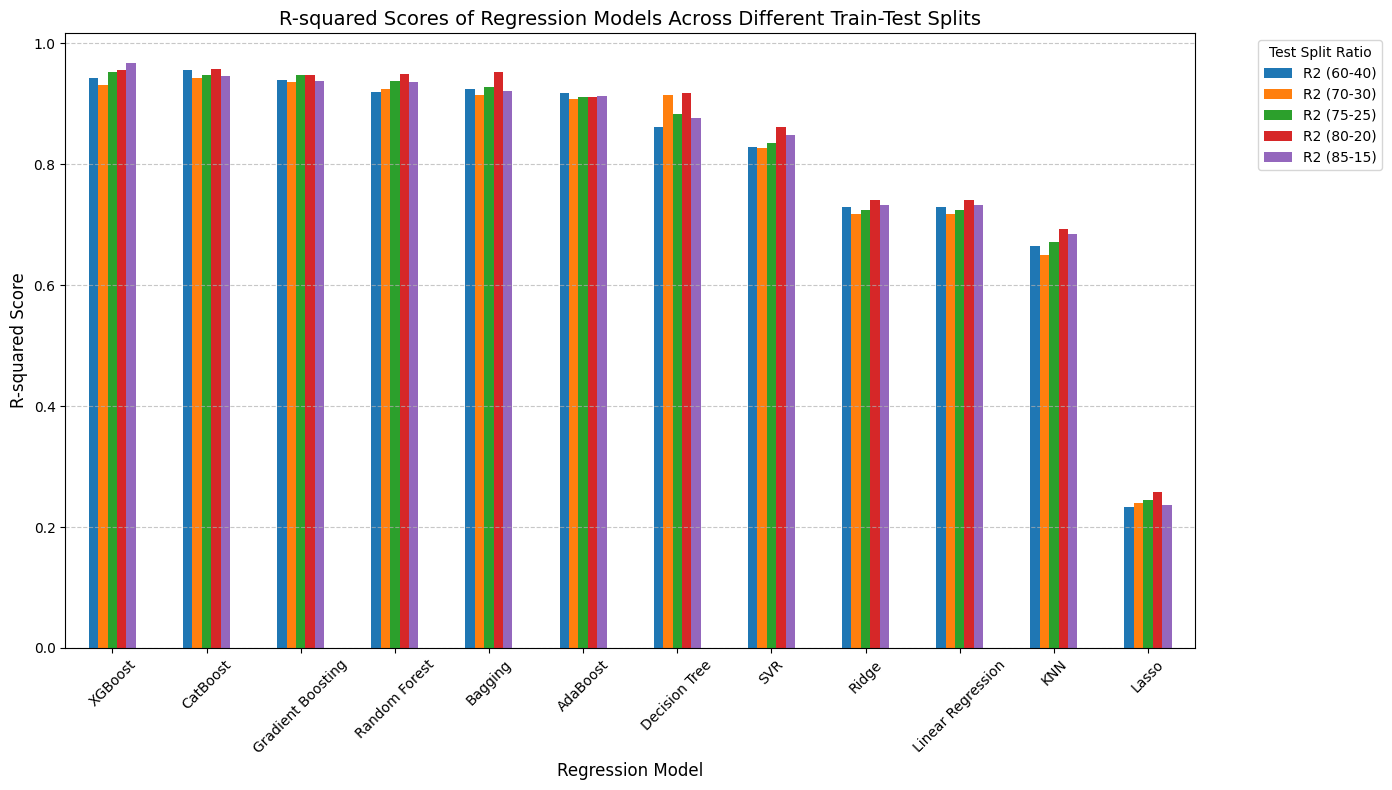

In [ ]:
import matplotlib.pyplot as plt

# Pivot data
plot_data = consolidated_results.pivot(index='Model', columns='Split', values='R2')

# Rename columns for clarity
plot_data.columns = [f"R2 ({col})" for col in plot_data.columns]

# Sort models by average R2 across splits
plot_data['Mean R2'] = plot_data.mean(axis=1)

plot_data = plot_data.sort_values('Mean R2', ascending=False)

# Remove helper column after sorting
plot_data = plot_data.drop(columns='Mean R2')

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
plot_data.plot(kind='bar', ax=ax)

ax.set_title('R-squared Scores of Regression Models Across Different Train-Test Splits', fontsize=14)
ax.set_xlabel('Regression Model', fontsize=12)
ax.set_ylabel('R-squared Score', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Test Split Ratio', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

###LSTM & GRU

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd # Ensure pandas is imported

# Define forecast_df (as it was intended for the time series data)
forecast_df = data.groupby("Year")["Units_Sold_"] \
    .sum().reset_index()
forecast_df.columns = ["ds", "y"]
forecast_df["ds"] = pd.to_datetime(forecast_df["ds"], format="%Y")

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    forecast_df[['y']].values
)


In [ ]:
def create_sequences(data, seq_length):

    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)


In [ ]:
seq_length = 8

X, y = create_sequences(scaled_data, seq_length)

# reshape for deep learning
X = X.reshape((X.shape[0], X.shape[1], 1))


In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=True, input_shape=(seq_length,1)))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

lstm_model.fit(X, y, epochs=200, batch_size=16)


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.1571
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.1399
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.1225
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1085
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0894
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0789
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0658
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0634
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0474
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0401
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0367
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0377
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0416
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0411
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0446
Epoch 16/200
1/1 ━━━━━━━━━━━━━━━━

In [ ]:
future_steps = 20   # number of future years/months

last_sequence = X[-1]

predictions = []

for _ in range(future_steps):

    pred = lstm_model.predict(
        last_sequence.reshape(1, seq_length, 1),
        verbose=0
    )

    predictions.append(pred[0][0])

    last_sequence = np.vstack([last_sequence[1:], pred])


In [ ]:
# get last year from original data
last_year = combined_df["ds"].dt.year.max()

# create future years
future_years = np.arange(last_year + 1, last_year + 1 + len(future_predictions))

In [ ]:
future_df = pd.DataFrame({
    "Year": future_years,
    "EV_Adoption_Forecast": future_predictions.flatten()
})

print(future_df)

    Year  EV_Adoption_Forecast
0   2046            2919316.50
1   2047            3060040.50
2   2048            3049899.50
3   2049            3019466.50
4   2050            2861683.75
5   2051            2872462.00
6   2052            2878833.75
7   2053            3020970.75
8   2054            3100429.50
9   2055            3046616.50
10  2056            2956873.75
11  2057            2923395.00
12  2058            2943411.75
13  2059            3022206.00
14  2060            3065513.25
15  2061            3073553.00
16  2062            3023300.50
17  2063            2970932.50
18  2064            2973977.00
19  2065            3021677.00


In [ ]:
future_predictions = scaler.inverse_transform(
    np.array(predictions).reshape(-1,1)
)

print(future_predictions)


[[2921251. ]
 [3657019. ]
 [4159974.8]
 [4711651. ]
 [3781749.2]
 [3922535.8]
 [4094230.5]
 [4798567. ]
 [5167766. ]
 [5293041.5]
 [5313401.5]
 [5292344.5]
 [5125310. ]
 [5094262.5]
 [5102356. ]
 [5140848. ]
 [5160720. ]
 [5174970.5]
 [5184006.5]
 [5185059. ]]


In [ ]:
last_date = pd.to_datetime(forecast_df['ds']).max()

future_dates = pd.date_range(
    start=last_date,
    periods=len(future_predictions)+1,
    freq='Y'
)[1:]


/tmp/ipython-input-2389/1709414440.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(


In [ ]:
future_df = pd.DataFrame({
    "ds": future_dates,
    "forecast": future_predictions.flatten()
})


In [ ]:
history_df = forecast_df[['ds','y']].copy()

history_df.rename(columns={"y":"value"}, inplace=True)
future_df.rename(columns={"forecast":"value"}, inplace=True)

history_df["type"] = "Actual"
future_df["type"] = "Forecast"

combined_df = pd.concat([history_df, future_df])


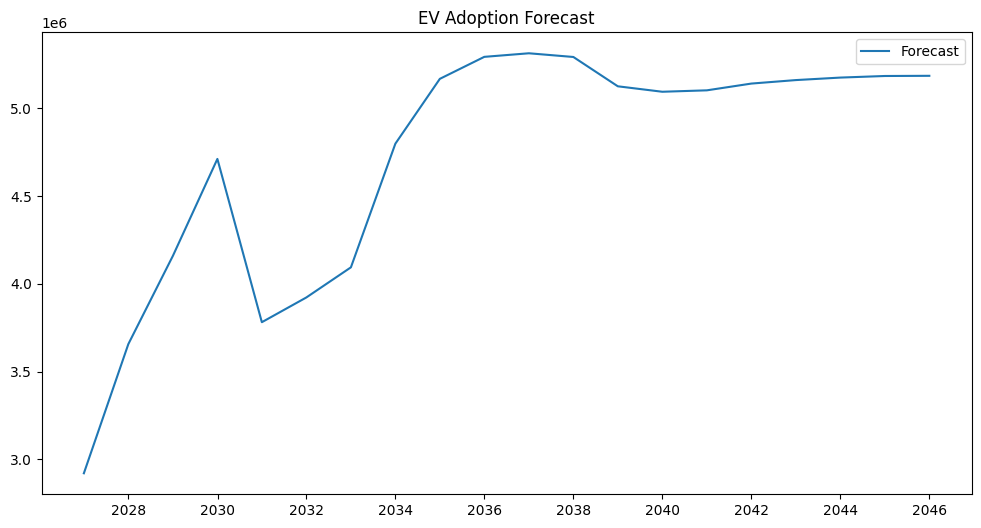

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))


forecast = combined_df[combined_df["type"]=="Forecast"]


plt.plot(forecast["ds"], forecast["value"], label="Forecast")

plt.legend()
plt.title("EV Adoption Forecast")
plt.show()


In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    forecast_df[['y']].values
)


In [ ]:
def create_sequences(data, seq_length):

    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)


In [ ]:
seq_length = 8

X, y = create_sequences(scaled_data, seq_length)

# reshape for deep learning
X = X.reshape((X.shape[0], X.shape[1], 1))


In [ ]:
gru_model = Sequential()

gru_model.add(GRU(64, return_sequences=True, input_shape=(seq_length,1)))
gru_model.add(GRU(32))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(X, y, epochs=100)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.1691
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1278
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0951
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0711
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0558
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0488
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0491
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0542
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0604
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0643
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0647
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0621
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0578
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0532
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0492
Epoch 16/100
1/1 ━━━━━━━━━━━━━━━

In [ ]:
future_steps = 20   # number of future years/months

last_sequence = X[-1]

predictions = []

for _ in range(future_steps):

    pred = gru_model.predict(
        last_sequence.reshape(1, seq_length, 1),
        verbose=0
    )

    predictions.append(pred[0][0])

    last_sequence = np.vstack([last_sequence[1:], pred])


In [ ]:
# get last year from original data
last_year = combined_df["ds"].dt.year.max()

# create future years
future_years = np.arange(last_year + 1, last_year + 1 + len(future_predictions))

In [ ]:
import pandas as pd
import numpy as np

# your predictions (already inverse transformed)
values = future_predictions.flatten()

# create correct years
years = np.arange(2026, 2026 + len(values))  # 2026 to 2046

# final forecast dataframe
future_df = pd.DataFrame({
    "Year": years,
    "EV_Adoption_Forecast": values
})

print(future_df)

    Year  EV_Adoption_Forecast
0   2026            2919316.50
1   2027            3060040.50
2   2028            3049899.50
3   2029            3019466.50
4   2030            2861683.75
5   2031            2872462.00
6   2032            2878833.75
7   2033            3020970.75
8   2034            3100429.50
9   2035            3046616.50
10  2036            2956873.75
11  2037            2923395.00
12  2038            2943411.75
13  2039            3022206.00
14  2040            3065513.25
15  2041            3073553.00
16  2042            3023300.50
17  2043            2970932.50
18  2044            2973977.00
19  2045            3021677.00


In [ ]:
last_date = pd.to_datetime(forecast_df['ds']).max()

future_dates = pd.date_range(
    start=last_date,
    periods=len(future_predictions)+1,
    freq='Y'
)[1:]


/tmp/ipython-input-2389/1709414440.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(


In [ ]:
future_df = pd.DataFrame({
    "ds": future_dates,
    "forecast": future_predictions.flatten()
})


In [ ]:
history_df = forecast_df[['ds','y']].copy()

history_df.rename(columns={"y":"value"}, inplace=True)
future_df.rename(columns={"forecast":"value"}, inplace=True)

history_df["type"] = "Actual"
future_df["type"] = "Forecast"

combined_df = pd.concat([history_df, future_df])


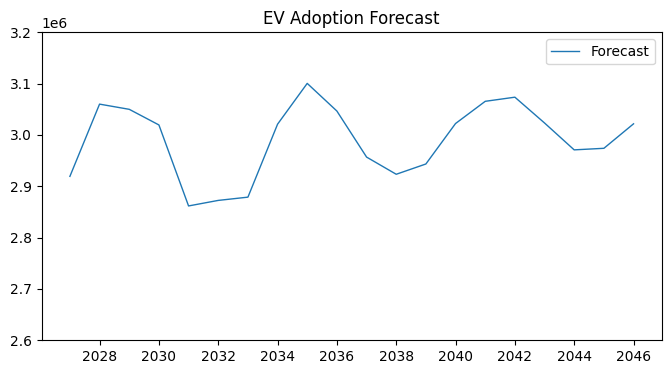

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))

forecast = combined_df[combined_df["type"]=="Forecast"]

plt.plot(
    forecast["ds"],
    forecast["value"],
    label="Forecast",
    linewidth=1
)

#  Y-axis starts from 2.6 with 0.10 difference
plt.ylim(bottom=2.6e6)
plt.yticks(np.arange(2.6e6, forecast["value"].max() + 0.1e6, 0.1e6))

plt.legend()
plt.title("EV Adoption Forecast")
plt.show()

In [ ]:
from sklearn.metrics import r2_score


y_pred_gru = gru_model.predict(X)

# Calculate R-squared score for the GRU model
r2_gru = r2_score(y, y_pred_gru)

print(f"R-squared : {r2_gru:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
R-squared : 0.86


In [ ]:
from sklearn.metrics import r2_score


y_pred_lstm = lstm_model.predict(X)

# Calculate R-squared score for the LSTM model
r2_lstm = r2_score(y, y_pred_lstm)

print(f" R-squared : {r2_lstm:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
 R-squared : 0.90


###FORECASTING prophet

In [ ]:
!pip install prophet

In [ ]:
ds= data
y= np.log(data['Units_Sold_'])

In [ ]:
from prophet import Prophet # Corrected import: 'Prophet' class, not 'prophet' module
forecast_df = data.groupby("Year")["Units_Sold_"].sum().reset_index() # Corrected 'group' to 'groupby' and 'units_sold' to 'Units_Sold_'
forecast_df.columns = ["ds","y"]
forecast_df["ds"] = pd.to_datetime(forecast_df["ds"], format="%Y") # Corrected column name to 'ds' and used forcast_df
forecast_df

,ds,y
0,2015-01-01,2664792
1,2016-01-01,2694055
2,2017-01-01,2551835
3,2018-01-01,2739394
4,2019-01-01,2713510
5,2020-01-01,3177723
6,2021-01-01,2928152
7,2022-01-01,3083481
8,2023-01-01,2663699
9,2024-01-01,2675736


In [ ]:
model = Prophet()
model.fit(forecast_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.


In [ ]:
future =  model.make_future_dataframe(periods=5, freq='Y')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [ ]:
forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']]


,ds,yhat,yhat_lower,yhat_upper
0,2015-01-01,2.683236e+06,2.448986e+06,2.907554e+06
1,2016-01-01,2.714101e+06,2.500544e+06,2.966404e+06
2,2017-01-01,2.733361e+06,2.502249e+06,2.961833e+06
3,2018-01-01,2.752933e+06,2.527775e+06,2.990082e+06
4,2019-01-01,2.778150e+06,2.556022e+06,3.006681e+06
5,2020-01-01,2.808966e+06,2.580649e+06,3.037428e+06
6,2021-01-01,2.828177e+06,2.596559e+06,3.071035e+06
7,2022-01-01,2.847700e+06,2.625081e+06,3.063133e+06
8,2023-01-01,2.872868e+06,2.638752e+06,3.104266e+06
9,2024-01-01,2.903684e+06,2.679379e+06,3.126883e+06


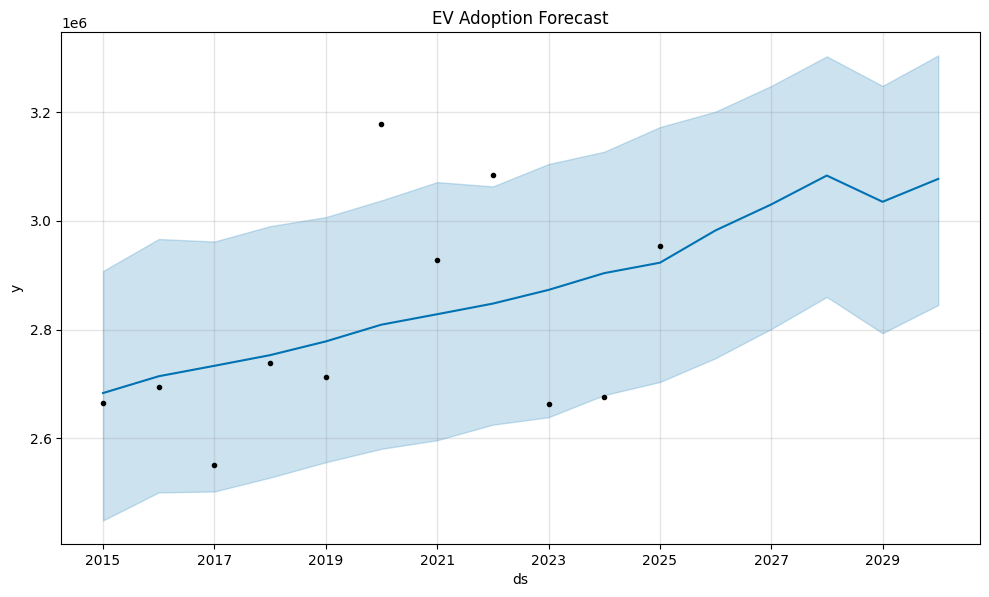

In [ ]:
model.plot(forecast)
plt.title("EV Adoption Forecast")
plt.show()


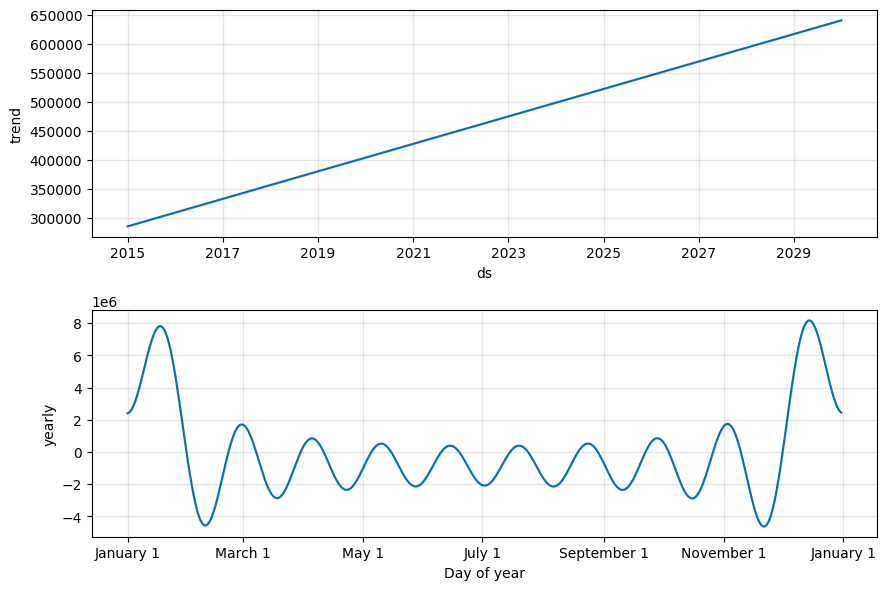

In [ ]:
model.plot_components(forecast)
plt.show()